## Importing libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np

## Optical and Electronic Correlations for AgS MOChas
This correlation plot shows the relationship between the HOMO-LUMO gap and electronic band gap and optical gaps for 1D fluorescent AgS MOChas. Both the HOMO-LUMO gap and electronic band gap were computed using Density Functional Theory (DFT) using the PBE functional and the D3 dispersion correction. No damping was used. The data for the optical gaps were obtained experimentally.

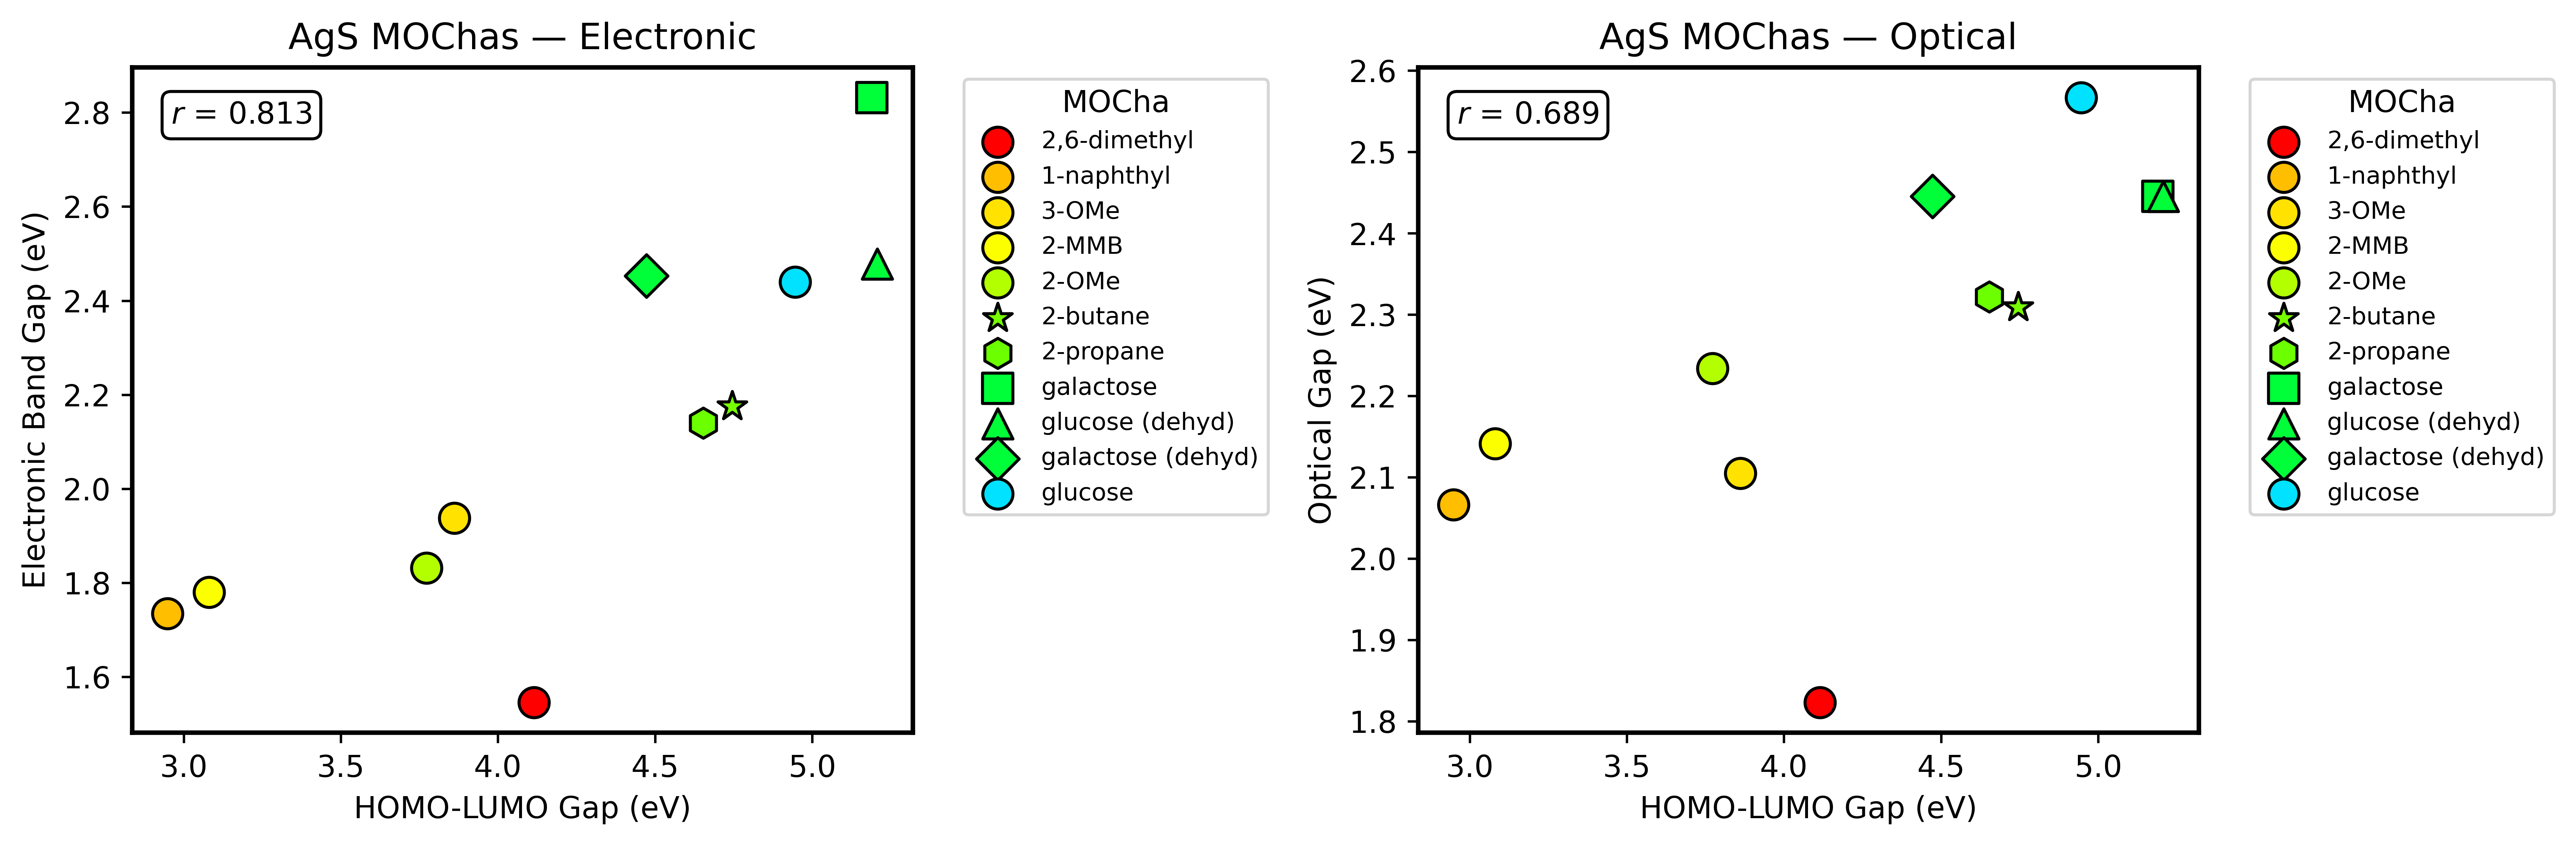

In [3]:
homo_lumo = np.array([
    4.115, 2.949, 3.861, 3.081, 3.773, 4.745, 4.653, 5.189, 5.207, 4.472, 4.945])

band_gap = np.array([
    1.546, 1.735, 1.938, 1.780, 1.832, 2.175, 2.140, 2.832, 2.478, 2.453, 2.440])

optical_gap = np.array([
    1.8233, 2.0664, 2.1050, 2.1414, 2.2339, 2.3088, 2.3217, 2.4454, 2.4454, 2.4454, 2.5670
]) 

colors = [
    "#ff0000", "#ffbe00", "#ffe200", "#fcff00", "#b3ff00", "#77ff00", "#6cff00",
    "#00ff38", "#00ff38", "#00ff38", "#00e2ff"]

labels = [
    "2,6-dimethyl", "1-naphthyl", "3-OMe", "2-MMB", "2-OMe", "2-butane", "2-propane",
    "galactose", "glucose (dehyd)", "galactose (dehyd)", "glucose"]

green_marker_shapes = ['s', '^', 'D']  # For #00ff38

fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=600)

def make_plot(ax, ydata, ylabel, title):
    r_value, _ = pearsonr(homo_lumo, ydata)
    green_index = 0
    count = 0
    for x, y, color, label in zip(homo_lumo, ydata, colors, labels):
        if color == "#00ff38":
            marker = green_marker_shapes[green_index]
            green_index += 1
        elif color == "#77ff00":
            marker = '*'
        elif color == "#6cff00":
            marker = 'h'
        else:
            marker = 'o'
        ax.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

    handles, legend_labels = ax.get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))
    ax.legend(unique.values(), unique.keys(), title="MOCha", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    ax.set_xlabel("HOMO-LUMO Gap (eV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    count += 1

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

make_plot(axs[0], band_gap, "Electronic Band Gap (eV)", "AgS MOChas — Electronic")
make_plot(axs[1], optical_gap, "Optical Gap (eV)", "AgS MOChas — Optical")

plt.tight_layout()
plt.show()
